<a href="https://colab.research.google.com/github/Ak-Space51/ml-astronomy/blob/main/week5_lens_vlm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSoT'26 - ML in Astronomy - Week 5: VLM Audit + CNN/CLIP/VLM Capstone (Starter)

**Goal:** Prompt a **vision-language model** to interpret Euclid cutouts, catch it hallucinating, then put three tools on trial on the *same* images - the **Week-3 CNN**, the **Week-4 CLIP** ranker, and this week's **VLM**. Finish with a short capstone reflection.

**Before you begin:**
1. Switch this notebook to a **GPU runtime** (`Runtime -> Change runtime type -> GPU`). The default VLM (`Qwen/Qwen2-VL-2B-Instruct`) runs on the T4 with no API key.
2. Read [`01-vlm-prompting-for-science.md`](../01-vlm-prompting-for-science.md) through [`04-comparing-cnn-clip-and-vlm.md`](../04-comparing-cnn-clip-and-vlm.md).
3. Have your Week-3 `galaxy_model.pth` and Week-4 CLIP scoring handy.

Replace each `TODO` with working code. **Do not** open the solution until you've genuinely attempted every TODO.

## Step 0 - Install libraries and pick a device

In [1]:
# Run once per Colab session.
!pip install -q datasets transformers accelerate qwen-vl-utils scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 34.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


## Step 1 - Reload the Euclid test set and take a stratified sample

VLM calls are slow, so we work on **30-50** cutouts. Make the sample **stratified**: include real lenses (label 1) *and* hard negatives (label 0) so precision/recall are meaningful. Keep images, labels, and ids aligned.

In [3]:
# TODO: load the test split and build a stratified sample of ~40 images.
from datasets import load_dataset
ds_test = load_dataset('mwalmsley/euclid_strong_lens_expert_judges', 'classification', split='test')
y_all = np.array(ds_test['label'])
rng = np.random.default_rng(42)
pos = rng.choice(np.where(y_all == 1)[0], size=20, replace=False)
neg = rng.choice(np.where(y_all == 0)[0], size=20, replace=False)
idx = np.concatenate([pos, neg]); rng.shuffle(idx)
images = [ds_test[int(i)]['image'].convert('RGB') for i in idx]
labels = y_all[idx]
print('sample size:', len(images), 'positives:', int(labels.sum()))

README.md:   0%|          | 0.00/1.08k [00:00<?, ?B/s]

classification/train-00000-of-00001.parq(…):   0%|          | 0.00/87.3M [00:00<?, ?B/s]

classification/test-00000-of-00001.parqu(…):   0%|          | 0.00/22.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5876 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1476 [00:00<?, ? examples/s]

sample size: 40 positives: 20


## Step 2 (optional) - Reference captions

Peek at 2-3 image+caption pairs from `Arbie333/gravitational_lensing` to see what a *good* human description of a lens sounds like - a benchmark for judging the VLM's evidence.

Dataset({
    features: ['image', 'response'],
    num_rows: 40
})


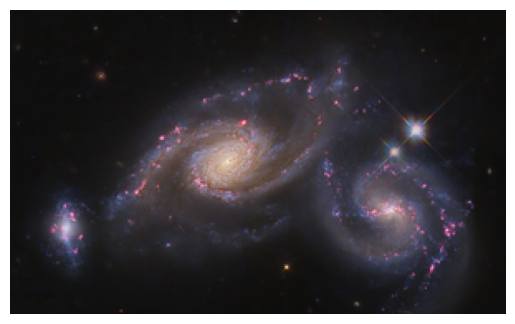

caption: This is a pair of interacting spiral galaxies. They are actually very close together, and not merely nearby on the sky. This image does not show an instance of strong gravitational lensing.


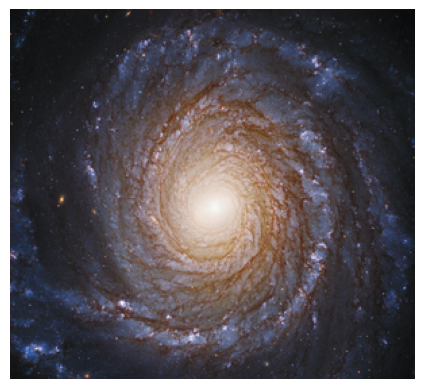

caption: This is a relatively nearby, beautiful spiral galaxy. It does not show an instance of strong gravitational lensing.


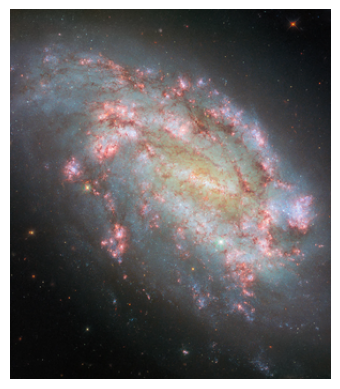

caption: This is a relatively nearby, beautiful spiral galaxy. It has lots of bright (pink) star forming regions. It does not show an instance of strong gravitational lensing.


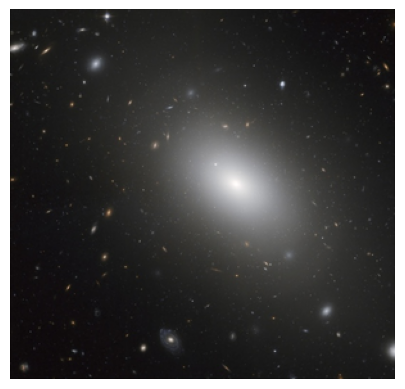

caption: This is a relatively nearby, massive elliptical galaxy. There are small satellite galaxies around it. This image does not show an instance of strong gravitational lensing.


In [6]:
# TODO (optional): load Arbie333/gravitational_lensing and print a couple of captions.
ref = load_dataset('Arbie333/gravitational_lensing', split='train')
print(ref)
cap_field = [c for c in ref.column_names if c != 'image'][0]
for i in range(4):
    plt.imshow(ref[i]['image']); plt.axis('off'); plt.show()
    print('caption:', ref[i][cap_field])


## Step 3 - Load the VLM and define the fixed prompt

Load `Qwen/Qwen2-VL-2B-Instruct` in half precision. Use the **fixed** prompt from [`01`](../01-vlm-prompting-for-science.md) for *every* image - consistency is what makes the results comparable and reproducible.

In [7]:
# TODO: load the model + processor and set the prompt.
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
model_id = 'Qwen/Qwen2-VL-2B-Instruct'
vlm = Qwen2VLForConditionalGeneration.from_pretrained(model_id, torch_dtype=torch.float16, device_map='auto')
processor = AutoProcessor.from_pretrained(model_id)

PROMPT = (
   'You are assisting an astronomer reviewing telescope cutouts for strong gravitational lensing.\n\n'
   'Look at this image. Strong lensing shows clear arcs, partial Einstein rings, or multiple images '
   'of a background source.\n\n'
   'Answer in this format:\n'
   'VERDICT: yes | no | uncertain\n'
   'EVIDENCE: one or two sentences describing what you see (or do not see)\n'
   'CAUTION: one sentence about what could be confused with lensing (e.g. spiral arms, mergers)')

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

...

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

## Step 4 - Run the VLM on every sampled image

Loop over the sample. For each image build the chat messages, generate with **low temperature / greedy decoding**, and store the raw text. One image per call keeps you off the T4 memory limit.

In [8]:
# TODO: generate a response per image and collect the raw text into `raw_answers`.
raw_answers = []
for img in images:
    messages = [{'role': 'user', 'content': [
        {'type': 'image', 'image': img}, {'type': 'text', 'text': PROMPT}]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[img], return_tensors='pt').to(vlm.device)
    with torch.no_grad():
        out = vlm.generate(**inputs, max_new_tokens=128, do_sample=False)
    reply = processor.batch_decode(out[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
    raw_answers.append(reply)
print(raw_answers[0])

VERDICT: yes
EVIDENCE: The image shows a clear arc, which is a characteristic of strong gravitational lensing. The arc is centered on a background source, and the surrounding area is distorted, indicating the presence of a strong gravitational lens.
CAUTION: The arc could also be caused by spiral arms or mergers in the background galaxy, but the presence of a clear arc is a strong indicator of strong gravitational lensing.


## Step 5 - Parse verdicts and score precision/recall

Parse the `VERDICT:` line, map `yes/no/uncertain` to a binary prediction, and compute precision/recall/F1 vs the true labels. **Document** how you treat `uncertain` (here: count as 'not a lens'; you could instead route it to human review).

In [13]:
# TODO: parse and score.
def parse_verdict(text):
  for line in text.splitlines():
    if line.strip().upper().startswith('VERDICT'):
      v = line.split(':', 1)[1].strip().lower()
      if 'yes' in v: return 'yes'
      if 'uncertain' in v: return 'uncertain'
      if 'no' in v: return 'no'
  return 'uncertain'

verdicts = [parse_verdict(t) for t in raw_answers]

vlm_pred = np.array([1 if v == 'yes' else 0 for v in verdicts])

from sklearn.metrics import classification_report

print('verdict counts:', {v: verdicts.count(v) for v in set(verdicts)})
print(classification_report(labels, vlm_pred, target_names=['not lens', 'lens']))

verdict counts: {'yes': 40}
              precision    recall  f1-score   support

    not lens       0.00      0.00      0.00        20
        lens       0.50      1.00      0.67        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Step 6 - Hallucination hunt

Find **at least two** cutouts where the VLM said `yes` but the true label is `0` (and your eyes agree it's not a lens). Show the image alongside the model's own `EVIDENCE` quote - these are your documented hallucinations. (See [`02`](../02-hallucination-and-human-in-the-loop.md).)

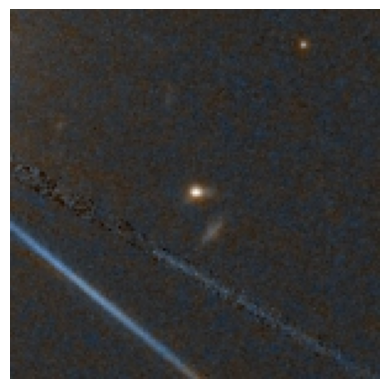

VLM said: VERDICT: yes
EVIDENCE: The image shows a clear arc, which is a characteristic of strong gravitational lensing. The arc is centered on a background source, and the surrounding area is distorted, indicating the presence of a strong gravitational lens.
CAUTION: The arc could also be caused by spiral arms or mergers in the background galaxy, but the presence of a clear arc is a strong indicator of strong gravitational lensing.


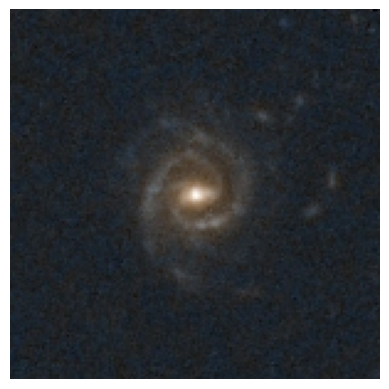

VLM said: VERDICT: yes
EVIDENCE: The image shows a clear arc, which is a characteristic of strong gravitational lensing. The arc is centered around the galaxy and extends outward, indicating the presence of a strong gravitational lens. There are no other visible features such as spiral arms or mergers that could be confused with lensing.
CAUTION: The arc could also be due to the galaxy itself, as it is a common feature of spiral galaxies. However, the arc is clearly visible and does not appear to be due to the galaxy itself.


In [14]:
# TODO: surface >=2 false-positive 'lens' claims with their evidence text.
halluc = [i for i in range(len(images)) if vlm_pred[i] == 1 and labels[i] == 0]
for i in halluc[:2]:
    plt.imshow(images[i]); plt.axis('off'); plt.show()
    print('VLM said:', raw_answers[i])

## Step 7 - Reload the Week-3 CNN and run it on the SAME images

Rebuild `GalaxyCNN`, load `galaxy_model.pth`, and predict on the sample (resize to the CNN's `64x64`). Expect **poor relevance** - it has no lens class and was trained on SDSS Galaxy Zoo, not Euclid. That's the wrong-task + domain-shift lesson ([`04`](../04-comparing-cnn-clip-and-vlm.md)), not a bug.

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
# TODO: define GalaxyCNN exactly as in Week 3, load weights, predict morphology per image.

import torch.nn as nn
from torchvision import transforms

class GalaxyCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),   # (B, 16, 64, 64)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (B, 16, 32, 32)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # (B, 32, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (B, 32, 16, 16)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                                 # (B, 8192)
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),                  # (B, num_classes) logits
        )

    def forward(self, x):                                 # x: (B, 3, 64, 64)
        x = self.features(x)
        x = self.classifier(x)
        return x
CLASSES = ['elliptical', 'spiral', 'spiral_barred']
model = GalaxyCNN(num_classes=len(CLASSES)).to(device)

model.load_state_dict(torch.load('drive/MyDrive/galaxy_model.pth', map_location=device)); model.eval()

tf = transforms.Compose([transforms.Resize((64,64)), transforms.ToTensor()])

cnn_pred = []
for img in images:
    x = tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        cnn_pred.append(CLASSES[model(x).argmax(1).item()])
print('CNN can only ever ans with morphology classes:', set(cnn_pred))


CNN can only ever ans with morphology classes: {'spiral', 'spiral_barred'}


## Step 8 - Week-4 CLIP scores on the SAME images

Reuse your Week-4 prompt bank and the `score = mean(lens sims) - mean(non-lens sims)` scorer on this sample, so all three tools see identical inputs.

In [28]:
# TODO: compute a CLIP lens score per image (see week4_lens_clip_solution.ipynb).
#   Reuse: load clip-vit-base-patch32, embed prompts + these images, normalise,
#   clip_scores = mean(lens-prompt sims) - mean(non-lens-prompt sims)  # shape (len(images),)

import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor

clip = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(device).eval()
clip_proc = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')

lens_prompts = ['a strong gravitational lens with an einstein ring', 'a gravitational arc next to a galaxy']

nonlens_prompts = ['a normal galaxy without gravitaional lensing', 'a spiral galaxy with curved arms but no gravitational lens arc']

all_prompts = lens_prompts + nonlens_prompts

n_lens = len(lens_prompts)

t_in = clip_proc(text=all_prompts, return_tensors='pt', padding=True).to(device)

with torch.no_grad():
    t_emb = F.normalize(clip.get_text_features(**t_in).pooler_output, dim=-1)

i_in = clip_proc(images=images, return_tensors='pt').to(device)

with  torch.no_grad():
    i_emb = F.normalize(clip.get_image_features(**i_in).pooler_output, dim=-1)
sims = (i_emb @ t_emb.T).cpu()

clip_scores = (sims[:, :n_lens].mean(1) - sims[:, n_lens:].mean(1)).numpy()

print('CLIP score range:', round(float(clip_scores.min()), 3), 'to', round(float(clip_scores.max()), 3))

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP score range: -0.015 to 0.011


## Step 9 - The three-way comparison figure

Put it all together: one row per image with the cutout and a caption stacking `true | CNN | CLIP | VLM`. Look for agreement on easy cases and **correlated** CLIP/VLM failures on spirals (the shared confusion from [`03`](../03-arcs-vs-spirals-confusion-physics.md)).

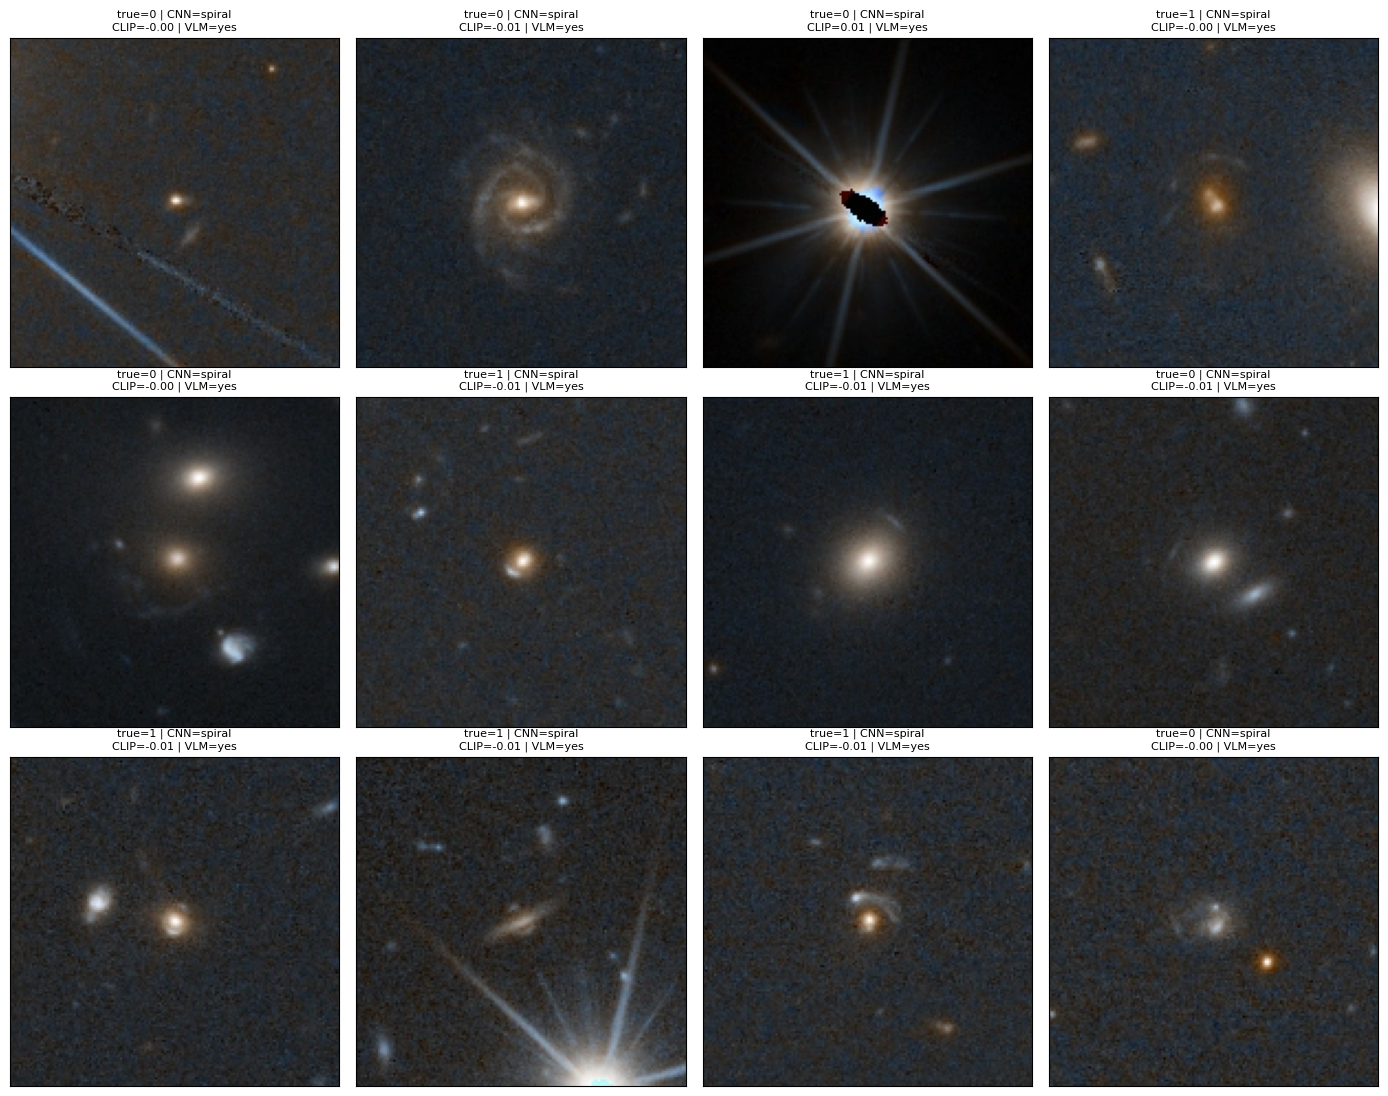

In [29]:
# TODO: build the comparison grid (or a pandas DataFrame table).
n = min(12, len(images))
fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax, i in zip(axes.ravel(), range(n)):
    ax.imshow(images[i]); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"true={labels[i]} | CNN={cnn_pred[i]}\nCLIP={clip_scores[i]:.2f} | VLM={verdicts[i]}",
                 fontsize=8)
plt.tight_layout(); plt.show()

## (Optional) Hosted-API fallback

If you'd rather use a hosted VLM, replace Steps 3-4 with an API call (e.g. Google AI Studio's free-tier Gemini). Keep the **same** fixed prompt and the same parsing so the rest of the notebook is unchanged.

```python
# import google.generativeai as genai
# genai.configure(api_key=USERDATA_GEMINI_KEY)  # store in Colab secrets, never hard-code
# gmodel = genai.GenerativeModel('gemini-1.5-flash')
# reply = gmodel.generate_content([PROMPT, img]).text
```

## Capstone Reflection *(~300 words)*

Write a cohesive reflection covering:

1. **Trust.** Given your VLM precision/recall and hallucinations, would you trust it unsupervised? Where does it earn or lose trust?
2. **The wrong tool.** What did running the Week-3 CNN on Euclid cutouts teach you about a model's limits outside its task and domain?
3. **The pipeline.** How would you combine CNN/CLIP/VLM + humans in a real Euclid/Rubin search? Where's your threshold, and how many candidates go to a human?
4. **Looking back.** From Week 1's first tensor to here - how has your sense of what AI can and can't do for science changed?

*(Replace this prompt with your answer.)*